In [1]:
import torch
from PIL import Image
import os
import numpy as np
from transformers import CLIPProcessor, CLIPModel
import matplotlib.pyplot as plt
import yaml

with open(os.path.expanduser("/work/cvcs2026/stochastic_parrots/config.yaml"), "r") as f:
    config = yaml.safe_load(f)

/homes/saresta/cvcs2026/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# CODICE DA STUDIARE

In [2]:
DEVICE = "cuda"
REF_IMAGES_DIR = config["paths"]["instance_images_dir"]  # Path to the reference image
LORA_GEN_DIR = config["paths"]["evaluation_dir"] + "/metrics/fidelity/images_lora"  # Directory to save images generated with Lora
BASE_GEN_DIR = config["paths"]["evaluation_dir"] + "/metrics/fidelity/images_base"  # Directory to save images generated without Lora

In [3]:
model_id = "openai/clip-vit-large-patch14"  # Model version: ViT Large (24 layers) with patch14 (each patch is 14x14 pixels)
model = CLIPModel.from_pretrained(model_id).to(DEVICE)  # Load the CLIP model (pretrained) and move it to the specified device (GPU or CPU)
processor = CLIPProcessor.from_pretrained(model_id)  # Load the CLIP processor to automatically preprocess images and text for the model

Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 590/590 [00:00<00:00, 808.38it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
def get_features(image_paths):
    images = [Image.open(p).convert("RGB") for p in image_paths]  # Load and convert images to RGB (to be sure)
    inputs = processor(images=images, return_tensors="pt").to(DEVICE) # Transform images into tensors (pytorch) and move to DEVICE
    
    with torch.no_grad():
        outputs = model.get_image_features(**inputs) # Get the image features from the CLIP model (vector of 1024 numbers)
        
        # 1. Extract the tensor from the model output (it can be a tensor diretly or a BaseModelOutputWithPooling, depends on the version of model)
        if torch.is_tensor(outputs):
            features = outputs
        else:
            # If it's a BaseModelOutputWithPooling, we look for the right field
            # In CLIP it's usually called 'image_embeds' or it's the first element
            features = getattr(outputs, "image_embeds", outputs[0])

        # 2. If the model output is 3D (Batch, Patches, Features), it outputs the features of all the patches. We need only "CLS Token" (the first patch)
        if len(features.shape) == 3:
            features = features[:, 0, :]

        # 3. Normalize the features to have unit norm (this is important for cosine similarity)
        features = features / features.norm(p=2, dim=-1, keepdim=True)
        
    return features


# Create a "footprint" of our reference images by averaging their features. This will be our "reference feature" to compare against generated images.

ref_paths = [os.path.join(REF_IMAGES_DIR, f) for f in os.listdir(REF_IMAGES_DIR) if f.endswith(('.png', '.jpg'))] # Get all image paths in the reference directory
ref_features = get_features(ref_paths)  # Get the features of all reference images (matrix of size [num_ref_images, feature_dim])
avg_ref_feature = ref_features.mean(dim=0, keepdim=True)  # Average the features to get a single "reference feature" (vector of size [1, feature_dim])
avg_ref_feature /= avg_ref_feature.norm(p=2, dim=-1, keepdim=True) # Normalize the average reference feature to have unit norm (important for cosine similarity)


# This function evaluates the fidelity of generated images by computing the cosine similarity. It returns the mean and std of the similarities for all generated images
def evaluate_folder(folder_path):
    gen_paths = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.png')]  # Get all generated image paths in the specified folder
    if not gen_paths: return 0
    
    all_similarities = []
    for path in gen_paths:
        gen_feat = get_features([path])  # Get the feature of the generated image (vector of size [1, feature_dim])
        sim = (gen_feat @ avg_ref_feature.T).item()  # Compute the cosine similarity between the generated image feature and the average reference feature (scalar)
        all_similarities.append(sim) # Append the similarity to the list of all similarities
    
    return np.mean(all_similarities), np.std(all_similarities)  # Return mean and std of the similarities for all generated images in the folder

In [5]:
# Esecuzione
print("Compute similarity for LoRA folder...")
mean_lora, std_lora = evaluate_folder(LORA_GEN_DIR)

print("Compute similarity for Base folder...")
mean_base, std_base = evaluate_folder(BASE_GEN_DIR)

print("\n--- RESULTS SUBJECT FIDELITY ---")
print(f"LoRA Model Score: {mean_lora:.4f} ± {std_lora:.4f}")
print(f"Base Model Score: {mean_base:.4f} ± {std_base:.4f}")
print(f"Fidelity increment: {((mean_lora - mean_base) / mean_base) * 100:.2f}%")

Compute similarity for LoRA folder...
Compute similarity for Base folder...

--- RESULTS SUBJECT FIDELITY ---
LoRA Model Score: 0.8635 ± 0.0339
Base Model Score: 0.7256 ± 0.0864
Fidelity increment: 19.01%


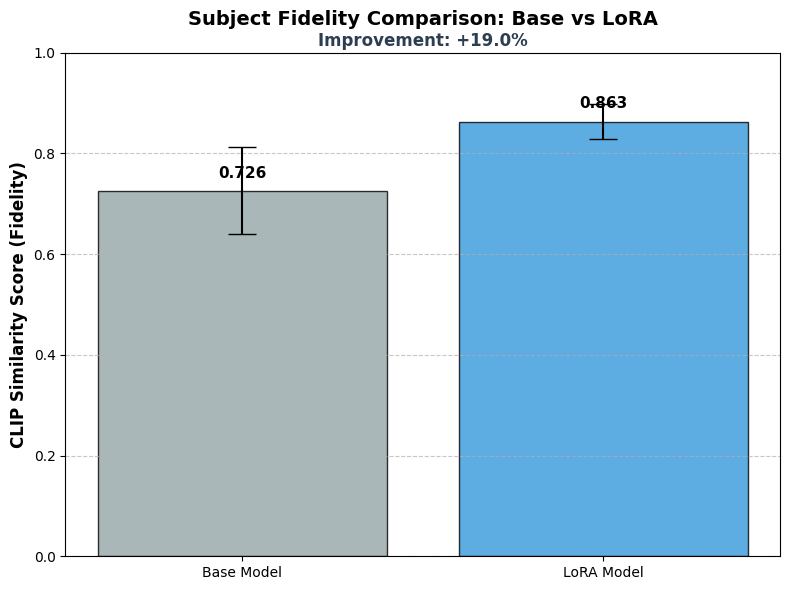

In [10]:
# Data for the bar chart
labels = ['Base Model', 'LoRA Model']
means = [mean_base, mean_lora]
stds = [std_base, std_lora]
colors = ['#95a5a6', '#3498db'] # Grigio per il base, Azzurro per il LoRA

# Create the bar chart with error bars
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, means, yerr=stds, capsize=10, color=colors, alpha=0.8, edgecolor='black')

# Personalization of the plot
plt.ylabel('CLIP Similarity Score (Fidelity)', fontsize=12, fontweight='bold')
plt.title('Subject Fidelity Comparison: Base vs LoRA', fontsize=14, fontweight='bold', pad=20)
plt.ylim(0, 1.0) # The CLIP score is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add the numerical values above the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Annotate the percentage increase
increment = ((mean_lora - mean_base) / mean_base) * 100
plt.annotate(f'Improvement: +{increment:.1f}%', 
             xy=(1, mean_lora), xytext=(0.5, mean_lora + 0.15),
             fontsize=12, color='#2c3e50', fontweight='bold', ha='center')

plt.tight_layout()

# Save the plot for the report
plt.show()